In [ ]:

import os
import re
import json
import stanza
import numpy as np
import pandas as pd
from tqdm import tqdm
import yargy
from yargy import Parser
from yargy import rule, and_, not_
from yargy.predicates import in_
from yargy.pipelines import morph_pipeline
from yargy.tokenizer import MorphTokenizer

from utils import load_json

from alldoc_parser.rules.entity_rules import missions
from alldoc_parser.rules.entity_rules import strategic_aims, strategic_priorities, strategic_directions
from alldoc_parser.rules.entity_rules import tasks, priorities, project_initiative
# from alldoc_parser.rules.entity_rules import aims, tasks, directions, priorities

from pdf2parser import Paragraph


c:\Users\whisk\anaconda3\envs\stat_analysis\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\whisk\anaconda3\envs\stat_analysis\Lib\site-packages\pymorphy2\analyzer.py:114: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:

syntax_parser = stanza.Pipeline('ru', processors='tokenize,pos,lemma,depparse')


2026-04-19 11:55:05 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES
2026-04-19 11:55:05 INFO: Downloaded file to C:\Users\whisk\AppData\Local\StanfordNLP\stanza\Cache\1.11.0\resources\resources.json
2026-04-19 11:55:05 INFO: Loading these models for language: ru (Russian):
| Processor | Package            |
----------------------------------
| tokenize  | syntagrus          |
| pos       | syntagrus_charlm   |
| lemma     | syntagrus_nocharlm |
| depparse  | syntagrus_charlm   |

2026-04-19 11:55:05 INFO: Using device: cpu
2026-04-19 11:55:05 INFO: Loading: tokenize
2026-04-19 11:55:07 INFO: Loading: pos
2026-04-19 11:55:10 INFO: Loading: lemma
2026-04-19 11:55:12 INFO: Loading: depparse
2026-04-19 11:55:13 INFO: Done loading processors!


In [3]:
missions_parser_a = missions.AnchorEntityParser(syntax_parser, True)
strategic_aims_parser_a = strategic_aims.AnchorEntityParser(syntax_parser, True)
strategic_priorities_parser_a = strategic_priorities.AnchorEntityParser(syntax_parser, True)
strategic_directions_parser_a = strategic_directions.AnchorEntityParser(syntax_parser, True)

priorities_parser_a = priorities.AnchorEntityParser(syntax_parser, True)
tasks_parser_a = tasks.AnchorEntityParser(syntax_parser, True)


strategic_aims_parser = strategic_aims.FreeEntityParser(syntax_parser, True)
strategic_priorities_parser = strategic_priorities.FreeEntityParser(syntax_parser, True)
strategic_directions_parser = strategic_directions.FreeEntityParser(syntax_parser, True)

project_initiatives_parser = project_initiative.FreeEntityParser(syntax_parser, True)
priorities_parser = priorities.FreeEntityParser(syntax_parser, True)
tasks_parser = tasks.FreeEntityParser(syntax_parser, True)


In [4]:

idx = -1
paths = [
    # r"C:\Users\whisk\OneDrive\Desktop\my_projects\StrategicPlanAnalysis\for_inference\kirovsk",
    # r"C:\Users\whisk\OneDrive\Desktop\my_projects\StrategicPlanAnalysis\for_inference\priozersk",
    # r"C:\Users\whisk\OneDrive\Desktop\my_projects\StrategicPlanAnalysis\for_inference\lomonos",
    # r"C:\Users\whisk\OneDrive\Desktop\my_projects\StrategicPlanAnalysis\for_inference\podporozh",
    # r"C:\Users\whisk\OneDrive\Desktop\my_projects\StrategicPlanAnalysis\for_inference\slanc",

    r"C:\Users\whisk\OneDrive\Desktop\my_projects\StrategicPlanAnalysis\for_inference\yamal"
]

path = paths[idx]
print(path)
df_paragraphs = pd.read_excel(os.path.join(path, "df_paragraphs.xlsx"), index_col=0)
# content = load_json(os.path.join(path, "content.json"))

if os.path.exists(os.path.join(path, "area_of_interest.json")):
    area_of_interest_ids = load_json(os.path.join(path, "area_of_interest.json"))

    area_of_interest = list()
    for item in area_of_interest_ids:
        area_of_interest.append(df_paragraphs.iloc[item["start"] : item["end"]])
    area_of_interest = pd.concat(area_of_interest, axis=0)

else:
    area_of_interest = df_paragraphs


C:\Users\whisk\OneDrive\Desktop\my_projects\StrategicPlanAnalysis\for_inference\yamal


In [5]:
# def blank_cleaner(s: str):
#     return re.sub("[ ]{2,}", " ", s).strip()

# row2content_entry = dict()
# for k, v in content.items():
#     for i, row in df_paragraphs.iterrows():
#         if re.match("".join([re.escape(x) for x in blank_cleaner(k)]), blank_cleaner(row["text"].strip())) is not None:
#             if k not in row2content_entry:
#                 row2content_entry[k] = [i]
#             else:
#                 row2content_entry[k].append(i)
                

In [6]:
def blank_cleaner(s: str):
    return re.sub("[ ]{2,}", " ", s).strip()

k = "Приоритет 2.3 «Транспортный комплекс»"
# k = "мероприятия по развитию, диверсификации, модернизации экономического комплекса"
for i, row in df_paragraphs.iterrows():
    if re.search("".join([re.escape(x) for x in blank_cleaner(k)]), blank_cleaner(row["text"].strip())) is not None:
        print(i)
    # break

In [7]:
df_paragraphs.iloc[31:]

,text,fontname
31,Раздел I,ZDOOVR+LiberationSerif
32,...,"MACOAO+LiberationSerif,Bold"
33,Ямальский район расположен на Крайнем Севере Е...,ZDOOVR+LiberationSerif
34,Общая площадь муниципального округа Ямальский ...,ZDOOVR+LiberationSerif
35,Длительное время экономической специализацией ...,ZDOOVR+LiberationSerif
...,...,...
1108,81,AQPOAA+Calibri
1109,"Численность детей, охваченных дошкольным и общ...","MACOAO+LiberationSerif,Bold"
1110,82,AQPOAA+Calibri
1111,"тью, %",ZDOOVR+LiberationSerif


In [8]:
anchors_mission = missions_parser_a(area_of_interest)
anchors_strategic_aim = strategic_aims_parser_a(area_of_interest)
anchors_strategic_priority = strategic_priorities_parser_a(area_of_interest)
anchors_strategic_direction = strategic_directions_parser_a(area_of_interest)

anchors_priority = priorities_parser_a(area_of_interest)
anchors_task = tasks_parser_a(area_of_interest)

anchors = (
    anchors_mission
    + anchors_strategic_aim
    + anchors_strategic_priority
    + anchors_strategic_direction

    + anchors_priority
    + anchors_task
)

def resolve_anchor_overlap(anchors: list):
    anchors_sorted = sorted(anchors, key=lambda x: x[0])
    anchors_resolved = list()
    for i, anchor_item in enumerate(anchors_sorted):
        if i < len(anchors_sorted) - 1:
            next_anchor_item = anchors_sorted[i+1]
            to_trunc = False
            for j, item in enumerate(anchor_item):
                if item[0] >= next_anchor_item[0][0]:
                    to_trunc = True
                    break
            if to_trunc:
                anchor_item_n = anchor_item[:j]
            else:
                anchor_item_n = anchor_item
            anchors_resolved.append(anchor_item_n)
        else:
            anchors_resolved.append(anchor_item)
    return anchors_resolved

anchors_resolved = resolve_anchor_overlap(anchors)
# anchors_resolved


100%|██████████| 1113/1113 [00:08<00:00, 125.28it/s]


In [15]:

strategic_aim_ids = strategic_aims_parser(area_of_interest)
strategic_priority_ids = strategic_priorities_parser(area_of_interest)
strategic_direction_ids = strategic_directions_parser(area_of_interest)

project_initiative_ids = project_initiatives_parser(area_of_interest)
priority_ids = priorities_parser(area_of_interest)
task_ids = tasks_parser(area_of_interest)

free_entity_ids = (
    strategic_aim_ids
    + strategic_priority_ids
    + strategic_direction_ids
    + project_initiative_ids
    + priority_ids
    + task_ids
)


100%|██████████| 1113/1113 [00:00<00:00, 19875.26it/s]


In [16]:
def resolve_free_anchor_overlap(free_entity_ids: list, anchor_entities: list[list]):
    free_entity_id2entity = dict()
    for item in free_entity_ids:
        if item[0] in free_entity_id2entity:
            print(item)
        free_entity_id2entity[item[0]] = item

    free_entity_ids_used = set()
    anchor_entity_ids_trunc = list()
    anchor_ids = set()
    for item in anchor_entities:
        item_anchor = item[0]
        anchor_ids.add(item_anchor[0])
        items_entity = item[1:]
        is_trunc = False
        for i, x in enumerate(items_entity):
            if x[0] in free_entity_id2entity:
                if free_entity_id2entity[x[0]][1] != x[1]:
                    is_trunc = True
                    break
                else:
                    free_entity_ids_used.add(x[0])
        if is_trunc:
            anchor_entity_ids_trunc.append([item_anchor] + items_entity[:i])
        else:
            anchor_entity_ids_trunc.append(item)

    free_entity_ids_used = free_entity_ids_used | anchor_ids

    free_entity_ids_trunc = [item for item in free_entity_ids if item[0] not in free_entity_ids_used]

    return free_entity_ids_trunc, anchor_entity_ids_trunc


In [17]:
free_entity_ids_trunc, anchor_entity_ids_trunc = resolve_free_anchor_overlap(free_entity_ids, anchors_resolved)

In [18]:
all_entities = list()
for item in free_entity_ids_trunc:
    all_entities.append(item)
for item in anchor_entity_ids_trunc:
    all_entities.extend(item[1:])
all_entities = sorted(all_entities, key=lambda x: x[0])


In [19]:
all_entities

[(599,
  'task',
  '1.  Повышение надежности энергоснабжения потребителей. Развитие  системы электроснабжения. ',
  'entity'),
 (600,
  'task',
  ' 2. Повышение энергосбережения и энергоэффективности организаций. ',
  'entity'),
 (601,
  'task',
  ' 3. Обеспечение населенных пунктов района  качественной  питьевой  водой. Обеспечение  бесперебойного и качественного водоснабжения и  водоотведения. ',
  'entity'),
 (602,
  'task',
  ' 4. Модернизация и реконструкция систем теплоснабжения. ',
  'entity'),
 (603, 'task', ' 5. Развитие газификации. ', 'entity'),
 (659,
  'task',
  'населения  доступными,  качественными  и  бесперебойными транспортными услугами. ',
  'entity'),
 (687,
  'task',
  ' 1. Развитие и модернизация сельского хозяйства, перерабатывающей  отрасли. ',
  'entity'),
 (688, 'task', ' 2.  Развитие и модернизация рыбной отрасли. ', 'entity'),
 (707,
  'task',
  '1.   Поддержка  субъектов  малого и среднего предпринимательства, в  том числе создание условий для сохранения и 

### Связывание

In [19]:
anchor_patterns = {
    "mission": [
        "миссия"
    ],
    "strategic_aim": [
        "стратегическая цель"
    ],
    "strategic_direction": [
        "стратегическое направление"
    ],
    "strategic_priority": [
        "стратегический приоритет"
    ],
    "project_initiative": [
        "проектная инициатива"
    ],
    "aim": [
        "цель"
    ],
    "direction": [
        "направление"
    ],
    "priority": [
        "приоритет"
    ],
    "task": [
        "задача"
    ]
}

tokenizer = MorphTokenizer()

def anchor_cleaner(s: str):
    patterns = [
        "В рамках реализации"
    ]
    regexs = re.compile("|".join(patterns), re.IGNORECASE)
    s_cln = s
    s_cln = regexs.sub(" ", s_cln)
    s_cln = re.sub("[ ]{2,}+", " ", s_cln)
    s_cln = " ".join(x.normalized for x in tokenizer(s_cln))
    return s_cln.strip()

def other_cleaner(s: str):
    s_cln = s
    s_cln = re.sub("[ ]{2,}+", " ", s_cln)
    s_cln = " ".join(x.normalized for x in tokenizer(s_cln))
    return s_cln.strip()

def cleaner(s: str):
    s_cln = s
    s_cln = re.sub("[^А-Яа-яЁё0-9]+", " ", s)
    s_cln = re.sub("[ ]{2,}+", " ", s_cln)
    return s_cln.lower().strip()

def similarity(s1: str, s2: str):
    sim_scores = {
        "inclusion": inclusion(s1, s2),
        "jaccard": jaccard(s1, s2)
    }
    return max(sim_scores.values())

def inclusion(s1: str, s2: str):
    if s1 in s2 or s2 in s1:
        return 1
    return 0

def jaccard(s1: str, s2: str):
    s1_tok = s1.split()
    s2_tok = s2.split()
    if len(s1_tok) == 0 or len(s2_tok) == 0:
        return 0
    s1_set = set(s1_tok)
    s2_set = set(s2_tok)
    return len(s1_set.intersection(s2_set)) / min(len(s1_set), len(s2_set))


In [20]:
def build_entity_pattern(m: yargy.parser.Match):
    stop_words = list()
    for item in m.tokens:
        stop_words.append(item.value)
    pattern = [
        not_(in_(stop_words)).repeatable().optional(),
        morph_pipeline([" ".join(stop_words)])
    ]
    return pattern

def build_starting_context_pattern(s: str):
    pattern = [
        morph_pipeline([s])
    ]
    return pattern

def build_intercontext_pattern(s: str):
    stop_words = s.split()
    pattern = [
        not_(in_(stop_words)).repeatable().optional(),
        morph_pipeline([" ".join(stop_words)])
    ]
    return pattern

connection_patterns = [
    [
        "реализация",
        "E_subject",
        "путем реализации следующих",
        "E_object"
    ],
    [
        "E_object",
        ", направленные на создание условий для реализации",
        "E_subject"
    ]
]


In [21]:
THRESHOLD = 0.9

text_entities = list()
for free_entity in all_entities:
    text_entities.append(other_cleaner(cleaner(free_entity[2])))

connections2parents_semantic_anchor = dict()
for item in anchor_entity_ids_trunc:
    item_anchor = item[0]

    text_anchor = anchor_cleaner(cleaner(item_anchor[2]))
    sim_scores = np.array([similarity(text_anchor, other_text) for other_text in text_entities])
    sim_scores_corr = np.array([int(item_anchor[1] != x[1]) for x in all_entities])
    sim_scores = sim_scores * sim_scores_corr

    max_idx = np.argpartition(sim_scores, kth=-1)[-1]
    max_value = sim_scores[max_idx]
    if max_value >= THRESHOLD and all_entities[max_idx][0] != item_anchor[0]:
        if item_anchor[0] not in connections2parents_semantic_anchor:
            connections2parents_semantic_anchor[item_anchor[0]] = [all_entities[max_idx][0]]
        else:
            connections2parents_semantic_anchor[item_anchor[0]].append(all_entities[max_idx][0])

for item in tqdm(anchor_entity_ids_trunc):
    item_anchor = item[0]
    if item_anchor[0] in connections2parents_semantic_anchor:
        continue
    
    # if item_anchor[0] != 440:
    #     continue
    # if item_anchor[0] == 440:
    #     raise Exception

    for k, v in anchor_patterns.items():
        if k == item_anchor[1]:
            continue
        subject_parser = Parser(morph_pipeline(v))
        subject_m = subject_parser.find(item_anchor[2])
        if subject_m is None:
            continue

        is_found = False
        for pattern in connection_patterns:
            rule_list = list()
            for i, item in enumerate(pattern):
                if item == "E_subject":
                    rule_list.extend(build_entity_pattern(subject_m))
                elif item == "E_object":
                    rule_list.extend(build_intercontext_pattern(anchor_patterns[item_anchor[1]][0]))
                else:
                    rule_list.extend(build_intercontext_pattern(item))
            parser_pattern = Parser(rule(*rule_list))
            pattern_m = parser_pattern.find(item_anchor[2])
            if pattern_m is not None:
                is_found = True
                break

        if not is_found:
            continue

        entities_cur = list()
        for i, item in enumerate(all_entities):
            if item[0] >= item_anchor[0]:
                break
            entities_cur.append(item)

        is_found_2 = False
        for item in entities_cur[::-1]:
            if item[1] == k:
                is_found_2 = True
                break

        if is_found_2:
            if item_anchor[0] not in connections2parents_semantic_anchor: 
                connections2parents_semantic_anchor[item_anchor[0]] = [item[0]]
            else:
                connections2parents_semantic_anchor[item_anchor[0]].append(item[0])


100%|██████████| 15/15 [00:20<00:00,  1.35s/it]


In [22]:
def sorter(l: list):
    return l

semantic_relation_types = dict()
for k, v in connections2parents_semantic_anchor.items():
    child = None
    for item in anchor_entity_ids_trunc:
        if item[0][0] == k:
            child = item[0]
            break
    parent = None
    for item in all_entities:
        if item[0] == sorter(v)[0]:
            parent = item
            break

    if child is not None and parent is not None:
        if child[1] not in semantic_relation_types:
            semantic_relation_types[child[1]] = [parent[1]]
        else:
            semantic_relation_types[child[1]].append(parent[1])

for k, v in semantic_relation_types.items():
    semantic_relation_types[k] = sorted(set(v))
    

In [23]:
connections2parents_semantic_anchor

{440: [438],
 443: [438],
 451: [449],
 454: [449],
 464: [462],
 466: [462],
 480: [478],
 482: [478],
 494: [478],
 496: [478],
 516: [514],
 528: [526],
 530: [526]}

In [24]:
semantic_relation_types

{'task': ['project_initiative']}

In [25]:
edges = dict()
for item in anchor_entity_ids_trunc:
    item_anchor = item[0]
    item_entities = item[1:]
    parent = connections2parents_semantic_anchor.get(item_anchor[0])
    if parent is not None:
        parent = sorter(parent)[0]
        for x in item_entities:
            if x[0] not in edges:
                edges[x[0]] = [parent]
            else:
                edges[x[0]].append(parent)

for k, v in semantic_relation_types.items():
    parent_type = sorter(v)[0]
    for i, entity in enumerate(all_entities):
        if entity[1] != k or entity[0] in edges:
            continue
        for j in range(i, -1, -1):
            if all_entities[j][1] == parent_type:
                edges[entity[0]] = [all_entities[j][0]]
                break
    # raise Exception
    # break

In [26]:
edges

{441: [438],
 442: [438],
 444: [438],
 452: [449],
 453: [449],
 455: [449],
 465: [462],
 467: [462],
 468: [462],
 469: [462],
 481: [478],
 483: [478],
 484: [478],
 485: [478],
 486: [478],
 487: [478],
 488: [478],
 489: [478],
 495: [478],
 497: [478],
 498: [478],
 499: [478],
 517: [514],
 518: [514],
 519: [514],
 520: [514],
 529: [526],
 531: [526],
 532: [526],
 533: [526],
 534: [526],
 507: [504],
 508: [504],
 509: [504],
 510: [504]}

In [27]:
type2name = {
    "mission": "миссия",
    "strategic_aim": "стратегическая цель",
    "strategic_direction": "стратегическое направление",
    "strategic_priority": "стратегический приоритет",
    "project_initiative": "проектная инициатива",
    "aim": "цель",
    "direction": "направление",
    "priority": "приоритет",
    "task": "задача"
}

df_results = list()
for item in all_entities:
    df_results.append({
        "индекс": item[0],
        "текст": item[2],
        "тип": type2name[item[1]],
        "к чему относится": ", ".join([str(x) for x in edges[item[0]]]) if item[0] in edges else ""
    })
df_results = pd.DataFrame(df_results)


In [30]:
print(os.path.basename(path))
df_results.to_excel(f"./vistuplenie/{os.path.basename(path)}.xlsx")

slanc


In [29]:
df_results

,индекс,текст,тип,к чему относится
0,415,Приоритетное стратегическое направление 1: «Эф...,стратегическое направление,
1,431,Стратегия социально-экономического развития на...,стратегическое направление,
2,432,В перспективе в структуре экономики Сланцевско...,стратегическое направление,
3,433,В условиях достаточной удаленности от Санкт-Пе...,стратегическое направление,
4,434,В основе реализации стратегии социально-эк...,стратегическое направление,
5,438,ПРОЕКТНАЯ ИНИЦИАТИВА 1. – «Индустриальное лиде...,проектная инициатива,
6,441,▪ Создание регионального промышленного кластер...,задача,438
7,442,▪ Создание условий для интеграции системы проф...,задача,438
8,444,▪ Обновление и модернизация материально-технич...,задача,438
9,449,ПРОЕКТНАЯ ИНИЦИАТИВА 2. – «Сланцы – многоотрас...,проектная инициатива,


(array([10.,  9.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([ -40. ,   69.3,  178.6,  287.9,  397.2,  506.5,  615.8,  725.1,
         834.4,  943.7, 1053. ]),
 <BarContainer object of 10 artists>)

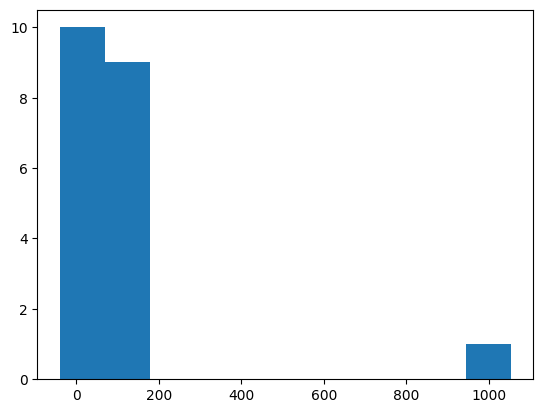

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats.mstats import winsorize
plt.hist(np.array([92, 19, 101, 58, 1053, 91, 26, 78, 10, 13, -40, 101, 86, 85, 15, 89, 89, 28, -5, 41]))

(array([2., 3., 2., 1., 1., 1., 0., 1., 4., 5.]),
 array([ -5. ,   5.6,  16.2,  26.8,  37.4,  48. ,  58.6,  69.2,  79.8,
         90.4, 101. ]),
 <BarContainer object of 10 artists>)

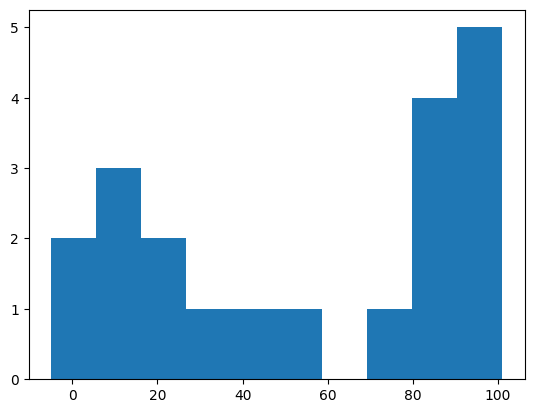

In [4]:
plt.hist(winsorize(np.array([92, 19, 101, 58, 1053, 91, 26, 78, 10, 13, -40, 101, 86, 85, 15, 89, 89, 28, -5, 41]), limits=[0.05, 0.05]))